In [1]:
!pip install efficientnet_pytorch
!pip install neptune-client

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16446 sha256=dadfeb0f66ab131afa3c05b9c78147835a4845d7eabfb08d5b414e29d2891b7f
  Stored in directory: /root/.cache/pip/wheels/0e/cc/b2/49e74588263573ff778da58cc99b9c6349b496636a7e165be6
Successfully built efficientnet-pytorch
     |████████████████████████████████| 288 kB 805 kB/s            
  Preparing metadata (setup.py) ... done
     |████████████████████████████████| 67 kB 4.5 MB/s             
  Preparing metadata (setup.py) ... done
  Created wheel for neptune-client: filename=neptune_client-0.14.1-py2.py3-none-any.whl size=500690 sha256=2a69308f06159c813dc8c65be16347738c2f51ce1da82841a11deb4d97496033
  Stored in directory: /root/.cache/pip/wheels/7a/e6/01/1349de3d7820de0659f9d1ac01ac92375131d4cbd9cc923378
  Created wheel for strict-rfc3339: filename=strict_rfc3339-0.7-py3-none-any.whl size=18149 sha256=29082854dbefc8f5c3142082ddde80fee96feb

In [2]:
import os
import time
import random
import yaml

import numpy as np
import cv2 as cv
import pandas as pd
import neptune.new as neptune
import matplotlib.pyplot as plt

import efficientnet_pytorch

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from pathlib import Path
from tqdm import tqdm

from albumentations import (
    Compose, Normalize, Transpose, HorizontalFlip,
    VerticalFlip, RandomRotate90, RandomScale
)
from albumentations.pytorch import ToTensorV2

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
base_dir = Path('/kaggle/input/cassava-leaf-disease-classification')
custom_data_base_dir = Path('/kaggle/input/cassava-dataset-splitted')
train_img_dir = f'{base_dir}/train_images'
train_df = pd.read_csv(f'{custom_data_base_dir}/cassava_splitted.csv')

In [7]:
train_df.head()

,image_id,label,label_name,fold
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB),2
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD),2
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD),1
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD),1
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD),2


In [8]:
class Config:
    cfg = {
        'seed': 42,
        'validation_fold': 0,
        'num_classes': 5,
        'image_size': (512, 512),
        'weight_decay': 1e-6,
        'batch_size': 32,
        'learning_rate': 0.001,
        'criterion': 'cross_entropy',
        'warm_restarts_T_0': 10,
        'warm_restarts_eta_min': 1e-6,
        'epochs': 10,
        'patience': 10,
        'num_workers': 8
        
    }
    
    neptune_settings = {
        'active': True,
        'log_artifacts': False
    }

In [9]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    
seed_everything(Config.cfg['seed'])

In [10]:
def get_neptune_config(config_path):
    with open(config_path) as f:
        neptune_config = yaml.load(f, Loader=yaml.FullLoader)
    return neptune_config

In [11]:
neptune_config = get_neptune_config('/kaggle/input/neptune-configuration-file/neptune_config.yaml')

In [12]:
if Config.neptune_settings['active']:
    neptune_run = neptune.init(
        project = neptune_config['project'],
        api_token = neptune_config['api_token']
    )
    
    neptune_run['my_params'] = Config.cfg

https://app.neptune.ai/oleh.komenchuk/cassava-model-train/e/CAS-42
Remember to stop your run once you’ve finished logging your metadata (https://docs.neptune.ai/api-reference/run#stop). It will be stopped automatically only when the notebook kernel/interactive console is terminated.


In [13]:
class CassavaDataset(Dataset):
    def __init__(self, df, image_size, augments=None):
        self.df = df.image_id.tolist()
        self.targets = df['label'].tolist()
        self.image_size = image_size
        self.augments = augments
        
    def __getitem__(self, idx):
        image = cv.imread(os.path.join(train_img_dir, self.df[idx]))
        image = cv.resize(image, self.image_size)
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        
        if self.augments:
            image = self.augments(image=image)['image']
            
        y = torch.tensor(self.targets[idx], dtype=torch.long)
        
        return {'X': image, 'y': y}
    
    def __len__(self):
        return len(self.targets)

In [16]:
class Augments:
    train_augments = Compose([
        Transpose(p=.5),
        HorizontalFlip(p=.5),
        VerticalFlip(p=.5),
        RandomRotate90(),
        Normalize(mean=[.485, .456, .406],
                  std=[.229, .224, .225],
                  p=1.),
        ToTensorV2(p=1.),
    ],
    p=1.,
    )
    
    val_augments = Compose([
        Normalize(mean=[.485, .456, .406],
                  std=[.229, .224, .225],
                  p=1.),
        ToTensorV2(p=1.),
    ],
    p=1.,
    )

In [17]:
def efficientnet_b0(num_classes):
    model = efficientnet_pytorch.EfficientNet.from_pretrained('efficientnet-b0')
    model._fc = nn.Linear(in_features=1280,
                          out_features=num_classes,
                          bias=True)
    return model

In [18]:
def efficientnet_b4(num_classes):
    model = efficientnet_pytorch.EfficientNet.from_pretrained('efficientnet-b4')
    model._fc = nn.Linear(in_features=1792,
                          out_features=num_classes,
                          bias=True)
    return model

In [19]:
def resnet_18(num_classes):
    model = torch.hub.load('pytorch/vision:v0.10.1', 'resnet18', pretrained=True)
    model.classifier = nn.Linear(in_features=512,
                                 out_features=num_classes,
                                 bias=True)
    return model

In [20]:
def resnet_101(num_classes):
    model = torch.hub.load('pytorch/vision:v0.10.1', 'resnet101', pretrained=True)
    model.classifier = nn.Linear(in_features=2048,
                                 out_features=num_classes,
                                 bias=True)
    return model

In [21]:
class Trainer:
    def __init__(self, model, optimizer, criterion, loss_metric, score_metric, scheduler, device='cuda:0'):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.loss_metric = loss_metric
        self.score_metric = score_metric
        self.scheduler = scheduler
        self.device = device
        
        self.best_valid_score = -np.inf
        self.n_patience = 0
        
        self.messages = {
            "batch": "[{}: {}/{}] loss: {:.5f}, score: {:.5f}, time: {} s",
            "epoch": "[Epoch {}: {}] loss: {:.5f}, score: {:.5f}, time: {} s",
            "checkpoint": "The score improved from {:.5f} to {:.5f}. Save model to '{}'",
            "patience": "\nValid score didn't improve last {} epochs."
        }
        
    
    def fit(self, epochs, train_loader, valid_loader, save_path, patience):
        history = {
            "train_loss": [],
            "train_score": [],
            "valid_loss": [],
            "valid_score": [],
        }
        
        for num_epoch in range(1, epochs + 1):
            self.info_message(f'Epoch: {num_epoch}')
            
            if Config.neptune_settings['active']:
                neptune_run['lr'].log(self.optimizer.param_groups[0]['lr'])
            
            train_loss, train_score, train_time = self.train_epoch(train_loader, num_epoch)
            valid_loss, valid_score, valid_time = self.valid_epoch(valid_loader)
            
            history["train_loss"].append(train_loss)
            history["train_score"].append(train_score)
            history["valid_loss"].append(valid_loss)
            history["valid_score"].append(valid_score)
            
            self.info_message(
                self.messages['epoch'], 'Train', num_epoch, train_loss, train_score, train_time
            )
            
            if Config.neptune_settings['active']:
                neptune_run['train_loss'].log(train_loss)
                neptune_run['train_accuracy'].log(train_score)
            
            self.info_message(
                self.messages['epoch'], 'Train', num_epoch, valid_loss, valid_score, valid_time
            )
            
            if Config.neptune_settings['active']:
                neptune_run['valid_loss'].log(valid_loss)
                neptune_run['valid_accuracy'].log(valid_score)
            
            if self.best_valid_score < valid_score:
                self.info_message(
                    self.messages['checkpoint'], self.best_valid_score, valid_score, save_path
                )
                self.best_valid_score = valid_score
                self.save_model(num_epoch, save_path)
                self.n_patience = 0
            else:
                self.n_patience += 1
                
            if self.n_patience >= patience:
                self.info_message(self.messages['patience'], patience)
                break
        
        return history
    
    def train_epoch(self, train_loader, epoch):
        self.model.train()
        t = time.time()
        train_loss = self.loss_metric()
        train_score = self.score_metric()
        
        for step, batch in enumerate(train_loader, 1):
            images = batch['X'].to(self.device)
            targets = batch['y'].to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(images)
            
            loss = self.criterion(outputs, targets)
            loss.backward()
            
            train_loss.update(loss.detach().item())
            train_score.update(targets, outputs.detach())
            
            self.optimizer.step()
            
            self.info_message(
                self.messages['batch'], 'Train', step, len(train_loader),
                train_loss.avg, train_score.avg, int(time.time() - t), end='\r'
            )
            
        self.scheduler.step()
        
        return train_loss.avg, train_score.avg, int(time.time() - t)
    
    def valid_epoch(self, valid_loader):
        self.model.eval()
        t = time.time()
        valid_loss = self.loss_metric()
        valid_score = self.score_metric()
        
        for step, batch in enumerate(valid_loader, 1):
            with torch.no_grad():
                images = batch['X'].to(self.device)
                targets = batch['y'].to(self.device)
                
                outputs = self.model(images)
                loss = self.criterion(outputs, targets)
                
                valid_loss.update(loss.detach().item())
                valid_score.update(targets, outputs)
                
            self.info_message(
                self.messages['batch'], 'Valid', step, len(valid_loader),
                valid_loss.avg, valid_score.avg, int(time.time() - t), end='\r'
            )
            
        return valid_loss.avg, valid_score.avg, int(time.time() - t)
    
    def save_model(self, num_epoch, save_path):
        torch.save(
            {
                'model_state_dict': self.model.state_dict(),
                'optimizer_state_dict': self.optimizer.state_dict(),
                'best_valid_score': self.best_valid_score,
                'num_epoch': num_epoch
            },
            save_path
        )
        
    @staticmethod
    def info_message(message, *args, end='\n'):
        print(message.format(*args), end=end)

In [22]:
class LossMeter:
    def __init__(self):
        self.avg = 0
        self.n = 0

    def update(self, val):
        self.n += 1
        self.avg = val / self.n + (self.n - 1) / self.n * self.avg

        
class AccMeter:
    def __init__(self):
        self.avg = 0
        self.n = 0
        
    def update(self, y_true, y_pred):
        y_true = y_true.cpu().numpy().astype(int)
        y_pred = y_pred.cpu().numpy().argmax(axis=1).astype(int)
        last_n = self.n
        self.n += len(y_true)
        true_count = np.sum(y_true == y_pred)
        self.avg = true_count / self.n + last_n / self.n * self.avg

In [23]:
train_fold = train_df[train_df["fold"] != Config.cfg['validation_fold']]
valid_fold = train_df[train_df["fold"] == Config.cfg['validation_fold']]

In [24]:
train_set = CassavaDataset(df=train_fold, image_size=Config.cfg['image_size'], augments=Augments.train_augments)
valid_set = CassavaDataset(df=valid_fold, image_size=Config.cfg['image_size'], augments=Augments.val_augments)

In [25]:
train_dataloader = DataLoader(
    train_set,
    batch_size=Config.cfg['batch_size'],
    shuffle=True,
    num_workers=Config.cfg['num_workers'],
)

valid_dataloader = DataLoader(
    valid_set,
    batch_size=Config.cfg['batch_size'],
    shuffle=False,
    num_workers=Config.cfg['num_workers']
)

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


In [26]:
model = efficientnet_b0(Config.cfg['num_classes'])
model.to(device)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


  0%|          | 0.00/20.4M [00:00<?, ?B/s]

Loaded pretrained weights for efficientnet-b0


EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d(padding=(0, 1, 0, 1), value=0.0)
  )
  (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
        (static_padding): ZeroPad2d(padding=(1, 1, 1, 1), value=0.0)
      )
      (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        32, 8, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        8, 32, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        32, 16, kernel_size=

In [27]:
optimizer = torch.optim.Adam(model.parameters(), lr=Config.cfg['learning_rate'], weight_decay=Config.cfg['weight_decay'],)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=Config.cfg['warm_restarts_T_0'],
    eta_min=Config.cfg['warm_restarts_eta_min']
)

In [28]:
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    loss_metric=LossMeter,
    score_metric=AccMeter
)

In [29]:
history = trainer.fit(
    epochs=Config.cfg['epochs'],
    train_loader=train_dataloader,
    valid_loader=valid_dataloader,
    save_path=f'{Config.cfg["validation_fold"]}_fold_model_effnetb0_best.torch.',
    patience=Config.cfg['patience']
)

Epoch: 1
[Epoch Train: 1] loss: 0.54804, score: 0.81043, time: 408 s
[Epoch Train: 1] loss: 0.58656, score: 0.82037, time: 92 s
The score improved from -inf to 0.82037. Save model to '0_fold_model_effnetb0_best.torch.'
Epoch: 2
[Epoch Train: 2] loss: 0.42848, score: 0.85206, time: 402 s
[Epoch Train: 2] loss: 0.44136, score: 0.85738, time: 86 s
The score improved from 0.82037 to 0.85738. Save model to '0_fold_model_effnetb0_best.torch.'
Epoch: 3
[Epoch Train: 3] loss: 0.38041, score: 0.86820, time: 402 s
[Epoch Train: 3] loss: 0.42695, score: 0.85757, time: 86 s
The score improved from 0.85738 to 0.85757. Save model to '0_fold_model_effnetb0_best.torch.'
Epoch: 4
[Epoch Train: 4] loss: 0.36005, score: 0.87512, time: 402 s
[Epoch Train: 4] loss: 0.51583, score: 0.80879, time: 86 s
Epoch: 5
[Epoch Train: 5] loss: 0.32056, score: 0.88933, time: 402 s
[Epoch Train: 5] loss: 0.39123, score: 0.87925, time: 87 s
The score improved from 0.85757 to 0.87925. Save model to '0_fold_model_effnetb0_

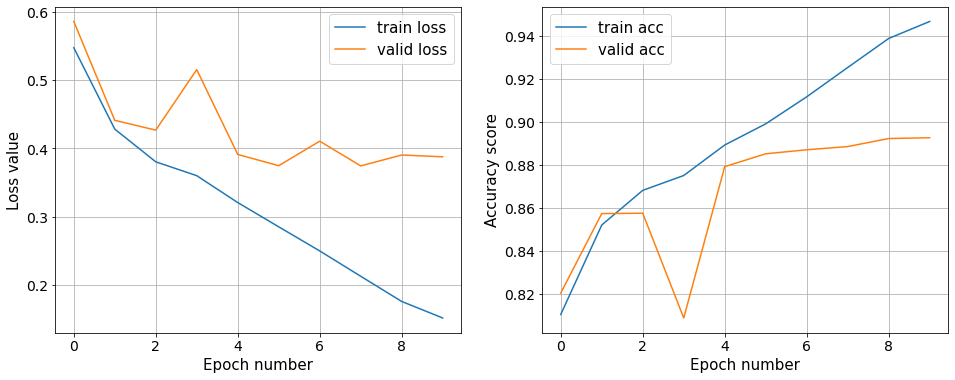

In [30]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['valid_loss'], label='valid loss')
plt.xticks(fontsize=14)
plt.xlabel("Epoch number", fontsize=15)
plt.yticks(fontsize=14)
plt.ylabel("Loss value", fontsize=15)
plt.legend(fontsize=15)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['train_score'], label='train acc')
plt.plot(history['valid_score'], label='valid acc')
plt.xticks(fontsize=14)
plt.xlabel("Epoch number", fontsize=15)
plt.yticks(fontsize=14)
plt.ylabel("Accuracy score", fontsize=15)
plt.legend(fontsize=15)
plt.grid();

In [33]:
if Config.neptune_settings["active"]:
    neptune_run.stop()

Shutting down background jobs, please wait a moment...
Done!


Waiting for the remaining 1 operations to synchronize with Neptune. Do not kill this process.


All 1 operations synced, thanks for waiting!
